<a href="https://colab.research.google.com/github/AritraStark/QViT/blob/master/vit_mnist_pennylane.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔮 Vision Transformer (ViT) on MNIST + Quantum ViT Architecture

## Task VIII — Classical ViT Implementation & Quantum Extension Sketch

**References:**
- Dosovitskiy et al. (2021) *An Image is Worth 16×16 Words: Transformers for Image Recognition at Scale* (ICLR 2021)
- Vaswani et al. (2017) *Attention Is All You Need* (NeurIPS 2017)
- Cherrat et al. (2022) *Quantum Vision Transformers* (arXiv:2209.08167)
- Mari et al. (2020) *Transfer learning in hybrid classical-quantum neural networks* (npj Quantum Information)

---

### Notebook Overview
1. **Classical ViT on MNIST** — Full implementation from scratch in TensorFlow/Keras
2. **Performance Evaluation** — Accuracy, confusion matrix, per-class metrics
3. **Attention Visualization** — Inspect what the transformer attends to
4. **Quantum ViT Architecture** — Detailed sketch & theoretical foundations


## Part 1 — Setup & Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.19.0
GPU available: True


## Part 2 — Data Loading & Preprocessing

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 28, 28, 1), Test: (10000, 28, 28, 1)
Label range: 0 – 9


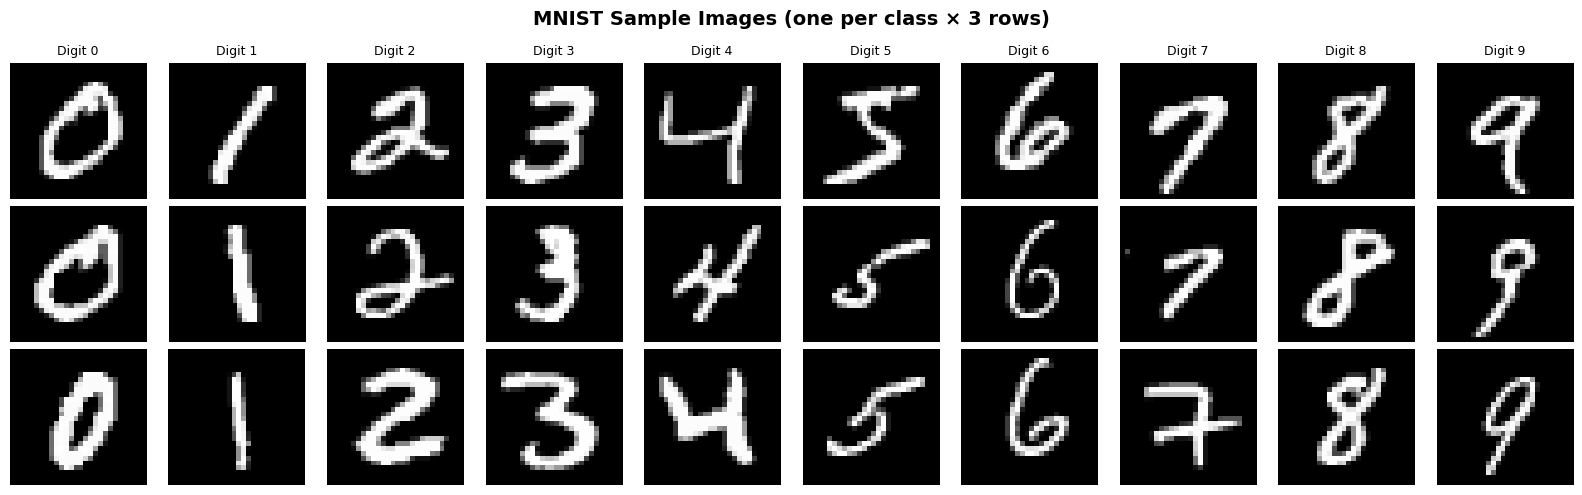

In [ ]:
# ─────────────────────────────────────────────
# MNIST Data Pipeline
# ─────────────────────────────────────────────
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize to [0, 1] and add channel dim: (N, 28, 28) → (N, 28, 28, 1)
x_train = x_train.astype(np.float32) / 255.0
x_test  = x_test.astype(np.float32)  / 255.0
x_train = x_train[..., np.newaxis]   # (60000, 28, 28, 1)
x_test  = x_test[..., np.newaxis]    # (10000, 28, 28, 1)

NUM_CLASSES = 10
print(f"Train: {x_train.shape}, Test: {x_test.shape}")
print(f"Label range: {y_train.min()} – {y_train.max()}")

# Visualise a sample grid
fig, axes = plt.subplots(3, 10, figsize=(16, 5))
fig.suptitle("MNIST Sample Images (one per class × 3 rows)", fontsize=14, fontweight='bold')
for row in range(3):
    for digit in range(10):
        idx = np.where(y_train == digit)[0][row]
        axes[row, digit].imshow(x_train[idx, :, :, 0], cmap='gray')
        axes[row, digit].axis('off')
        if row == 0:
            axes[row, digit].set_title(f'Digit {digit}', fontsize=9)
plt.tight_layout()
plt.show()

## Part 3 — ViT Hyperparameters

Following the ViT paper's notation:
- **P** = patch size
- **N** = number of patches = (H/P)²
- **D** = embedding dimension
- **L** = number of transformer layers
- **h** = number of attention heads
- **MLP size** = inner FF dimension

In [ ]:
# ─────────────────────────────────────────────
#  ViT Hyperparameters  (ViT-Tiny adapted for MNIST)
# ─────────────────────────────────────────────
IMG_SIZE    = 28      # Input image H=W
PATCH_SIZE  = 4       # P: each patch is 4×4 pixels
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2   # N = 49
EMBED_DIM   = 64      # D: latent vector size
NUM_HEADS   = 4       # Multi-head attention heads
NUM_LAYERS  = 6       # L: transformer encoder depth
MLP_DIM     = 128     # Feed-forward inner dim
DROPOUT     = 0.1     # Regularisation
BATCH_SIZE  = 256
EPOCHS      = 30
LR          = 1e-3

print(f"Image size   : {IMG_SIZE}×{IMG_SIZE}")
print(f"Patch size   : {PATCH_SIZE}×{PATCH_SIZE}")
print(f"Num patches  : {NUM_PATCHES}  (+1 CLS token = {NUM_PATCHES+1} tokens)")
print(f"Patch dim    : {PATCH_SIZE*PATCH_SIZE*1}   (P²×C)")
print(f"Embed dim    : {EMBED_DIM}")
print(f"Transformer layers: {NUM_LAYERS}")
print(f"Attention heads   : {NUM_HEADS}")

Image size   : 28×28
Patch size   : 4×4
Num patches  : 49  (+1 CLS token = 50 tokens)
Patch dim    : 16   (P²×C)
Embed dim    : 64
Transformer layers: 6
Attention heads   : 4


## Part 4 — ViT Building Blocks

### 4.1 Patch Embedding
Following §3.1 of the ViT paper: *"We reshape the image $\mathbf{x} \in \mathbb{R}^{H \times W \times C}$ into a sequence of flattened 2D patches $\mathbf{x}_p \in \mathbb{R}^{N \times (P^2 \cdot C)}$"* and project each patch with a trainable linear layer $\mathbf{E} \in \mathbb{R}^{(P^2 C) \times D}$.

In [ ]:
class PatchEmbedding(layers.Layer):
    """
    Split image into non-overlapping patches and linearly project each patch.
    Ref: ViT paper §3.1 — 'Patch + Position Embeddings'
    """
    def __init__(self, patch_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size
        self.embed_dim  = embed_dim
        # Linear projection E (Eq. 1 in ViT paper)
        self.projection = layers.Dense(embed_dim)

    def call(self, images):
        batch_size = tf.shape(images)[0]
        H, W, C = images.shape[1], images.shape[2], images.shape[3]
        P = self.patch_size
        # Reshape: (B, H, W, C) → (B, N, P*P*C)
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, P, P, 1],
            strides=[1, P, P, 1],
            rates=[1, 1, 1, 1],
            padding='VALID'
        )  # (B, H/P, W/P, P*P*C)
        num_patches = (H // P) * (W // P)
        patches = tf.reshape(patches, [batch_size, num_patches, P * P * C])
        # Linear projection → (B, N, D)
        return self.projection(patches)

    def get_config(self):
        config = super().get_config()
        config.update({'patch_size': self.patch_size, 'embed_dim': self.embed_dim})
        return config


# Quick sanity check
dummy = tf.zeros((2, 28, 28, 1))
pe = PatchEmbedding(PATCH_SIZE, EMBED_DIM)
out = pe(dummy)
print(f"PatchEmbedding output shape: {out.shape}")  # (2, 49, 64)

PatchEmbedding output shape: (2, 49, 64)


### 4.2 Learnable [CLS] Token & Positional Embeddings

The ViT paper prepends a *class token* $\mathbf{z}_0^0 = \mathbf{x}_{\text{class}}$ to the patch sequence. A **learnable 1D positional embedding** $\mathbf{E}_{\text{pos}} \in \mathbb{R}^{(N+1) \times D}$ is added to retain spatial information.

In [ ]:
class CLSTokenAndPositionalEmbedding(layers.Layer):
    """
    Prepend CLS token + add learnable 1-D positional embeddings.
    Ref: ViT paper Eq. 1 — z_0 = [x_class; x_p^1 E; ... ; x_p^N E] + E_pos
    """
    def __init__(self, num_patches, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.embed_dim   = embed_dim

    def build(self, input_shape):
        # CLS token: (1, 1, D)
        self.cls_token = self.add_weight(
            name='cls_token', shape=(1, 1, self.embed_dim),
            initializer='zeros', trainable=True
        )
        # Positional embedding: (1, N+1, D)
        self.pos_embed = self.add_weight(
            name='pos_embed', shape=(1, self.num_patches + 1, self.embed_dim),
            initializer='random_normal', trainable=True
        )
        super().build(input_shape)

    def call(self, patch_embeds):
        batch_size = tf.shape(patch_embeds)[0]
        # Broadcast CLS token across batch
        cls_tokens = tf.broadcast_to(self.cls_token, [batch_size, 1, self.embed_dim])
        # Concatenate: (B, N+1, D)
        x = tf.concat([cls_tokens, patch_embeds], axis=1)
        # Add positional embedding
        return x + self.pos_embed

    def get_config(self):
        config = super().get_config()
        config.update({'num_patches': self.num_patches, 'embed_dim': self.embed_dim})
        return config

### 4.3 Multi-Head Self-Attention (MSA)

The core attention mechanism from Vaswani et al., adapted as in ViT:
$$\text{Attention}(Q,K,V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$
where $Q,K,V = \mathbf{z}W_Q, \mathbf{z}W_K, \mathbf{z}W_V$.

In [ ]:
class MultiHeadSelfAttention(layers.Layer):
    """
    Multi-Head Self-Attention with optional attention weight return.
    Ref: ViT paper §3 — Eq. 2, Vaswani et al. 2017
    """
    def __init__(self, embed_dim, num_heads, dropout=0.0, **kwargs):
        super().__init__(**kwargs)
        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads
        self.scale     = self.head_dim ** -0.5

        self.qkv     = layers.Dense(3 * embed_dim, use_bias=False)
        self.proj    = layers.Dense(embed_dim)
        self.dropout = layers.Dropout(dropout)

    def call(self, x, training=False, return_attention=False):
        B, N, D = tf.shape(x)[0], tf.shape(x)[1], tf.shape(x)[2]

        # Compute Q, K, V and reshape to (B, heads, N, head_dim)
        qkv = self.qkv(x)                         # (B, N, 3D)
        qkv = tf.reshape(qkv, [B, N, 3, self.num_heads, self.head_dim])
        qkv = tf.transpose(qkv, [2, 0, 3, 1, 4]) # (3, B, heads, N, head_dim)
        q, k, v = qkv[0], qkv[1], qkv[2]

        # Scaled dot-product attention
        attn = tf.matmul(q, k, transpose_b=True) * self.scale  # (B, heads, N, N)
        attn = tf.nn.softmax(attn, axis=-1)
        attn = self.dropout(attn, training=training)

        # Weighted sum of values
        out = tf.matmul(attn, v)                  # (B, heads, N, head_dim)
        out = tf.transpose(out, [0, 2, 1, 3])     # (B, N, heads, head_dim)
        out = tf.reshape(out, [B, N, D])           # (B, N, D)
        out = self.proj(out)

        if return_attention:
            return out, attn
        return out

    def get_config(self):
        config = super().get_config()
        config.update({'embed_dim': self.embed_dim, 'num_heads': self.num_heads})
        return config

### 4.4 Transformer Encoder Block

Each block follows the ViT paper's Eq. 2–3:
$$\mathbf{z}'_\ell = \text{MSA}(\text{LN}(\mathbf{z}_{\ell-1})) + \mathbf{z}_{\ell-1}$$
$$\mathbf{z}_\ell = \text{MLP}(\text{LN}(\mathbf{z}'_\ell)) + \mathbf{z}'_\ell$$

Pre-LN formulation (more stable training than post-LN).

In [ ]:
class TransformerEncoderBlock(layers.Layer):
    """
    Single Transformer Encoder Block.
    Pre-LayerNorm variant for training stability.
    Ref: ViT paper §3 — Eq. 2 & 3
    """
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.attn  = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        # MLP with GELU activation (ViT paper §3)
        self.mlp = keras.Sequential([
            layers.Dense(mlp_dim, activation='gelu'),
            layers.Dropout(dropout),
            layers.Dense(embed_dim),
            layers.Dropout(dropout),
        ])
        self.dropout = layers.Dropout(dropout)

    def call(self, x, training=False, return_attention=False):
        # MSA sub-block (Pre-LN + residual)
        if return_attention:
            attn_out, attn_weights = self.attn(self.norm1(x), training=training,
                                               return_attention=True)
        else:
            attn_out = self.attn(self.norm1(x), training=training)
        x = x + self.dropout(attn_out, training=training)
        # MLP sub-block (Pre-LN + residual)
        x = x + self.mlp(self.norm2(x), training=training)

        if return_attention:
            return x, attn_weights
        return x

    def get_config(self):
        config = super().get_config()
        config.update({'embed_dim': self.embed_dim, 'num_heads': self.num_heads,
                        'mlp_dim': self.mlp_dim, 'dropout': self.dropout_rate})
        return config

### 4.5 Complete Vision Transformer Model

The full ViT pipeline (ViT paper Fig. 1):
$$\hat{y} = \text{LN}(\mathbf{z}_L^0) \xrightarrow{\text{MLP head}} \text{class probabilities}$$

The CLS token at position 0 is extracted after the final encoder block and passed through a classification head.

In [ ]:
def build_vit(
    img_size=IMG_SIZE, patch_size=PATCH_SIZE, num_classes=NUM_CLASSES,
    embed_dim=EMBED_DIM, num_layers=NUM_LAYERS, num_heads=NUM_HEADS,
    mlp_dim=MLP_DIM, dropout=DROPOUT
):
    """
    Build a Vision Transformer (ViT) model.
    Architecture follows Dosovitskiy et al. (2021) ICLR.

    Returns a compiled Keras Model.
    """
    num_patches = (img_size // patch_size) ** 2

    inputs = keras.Input(shape=(img_size, img_size, 1), name='image')

    # ── 1. Patch embedding ────────────────────────────────────────────────
    x = PatchEmbedding(patch_size, embed_dim, name='patch_embed')(inputs)

    # ── 2. CLS token + positional embedding ──────────────────────────────
    x = CLSTokenAndPositionalEmbedding(num_patches, embed_dim,
                                        name='cls_pos_embed')(x)
    x = layers.Dropout(dropout)(x)

    # ── 3. Transformer encoder (L blocks) ────────────────────────────────
    for i in range(num_layers):
        x = TransformerEncoderBlock(
            embed_dim, num_heads, mlp_dim, dropout,
            name=f'transformer_block_{i}'
        )(x)

    # ── 4. Pre-final LayerNorm ────────────────────────────────────────────
    x = layers.LayerNormalization(epsilon=1e-6, name='final_norm')(x)

    # ── 5. Extract CLS token (index 0) ───────────────────────────────────
    cls_output = x[:, 0, :]   # (B, D)

    # ── 6. Classification MLP head ────────────────────────────────────────
    # ViT paper uses a single linear layer for fine-tuning;
    # we use a small MLP head as in the pre-training stage
    x = layers.Dense(mlp_dim, activation='gelu', name='mlp_head_hidden')(cls_output)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, name='classifier')(x)

    model = keras.Model(inputs, outputs, name='ViT_MNIST')
    return model


model = build_vit()
model.summary()

Model: "ViT_MNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_embed (PatchEmbedding)    │ (None, 49, 64)         │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cls_pos_embed                   │ (None, 50, 64)         │         3,264 │
│ (CLSTokenAndPositionalEmbeddin… │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_0             │ (None, 50, 64)         │        33,280 │
│ (TransformerEncoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 50, 64)         │        33,280 │
│ (TransformerEncoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 50, 64)         │        33,280 │
│ (TransformerEncoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 50, 64)         │        33,280 │
│ (TransformerEncoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_4             │ (None, 50, 64)         │        33,280 │
│ (TransformerEncoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_5             │ (None, 50, 64)         │        33,280 │
│ (TransformerEncoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ final_norm (LayerNormalization) │ (None, 50, 64)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item (GetItem)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mlp_head_hidden (Dense)         │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 213,770 (835.04 KB)

 Trainable params: 213,770 (835.04 KB)

 Non-trainable params: 0 (0.00 B)

## Part 5 — Training

In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# Cosine-Decay with Warmup  (follows ViT paper training recipe)
# ─────────────────────────────────────────────────────────────────────────
total_steps   = (len(x_train) // BATCH_SIZE) * EPOCHS
warmup_steps  = total_steps // 10   # 10% warmup

class WarmupCosineDecay(keras.optimizers.schedules.LearningRateSchedule):
    """Linear warmup followed by cosine decay."""
    def __init__(self, base_lr, total_steps, warmup_steps):
        super().__init__()
        self.base_lr      = tf.cast(base_lr, tf.float32)
        self.total_steps  = tf.cast(total_steps, tf.float32)
        self.warmup_steps = tf.cast(warmup_steps, tf.float32)

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup_lr = self.base_lr * (step / self.warmup_steps)
        cosine_lr = self.base_lr * 0.5 * (
            1.0 + tf.math.cos(
                np.pi * (step - self.warmup_steps) / (self.total_steps - self.warmup_steps)
            )
        )
        return tf.where(step < self.warmup_steps, warmup_lr, cosine_lr)

lr_schedule = WarmupCosineDecay(LR, total_steps, warmup_steps)

model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=8,
                                   restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                       patience=4, verbose=1, min_lr=1e-6),
]

print(f"Training ViT on MNIST for up to {EPOCHS} epochs...")
history = model.fit(
    x_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Training ViT on MNIST for up to 30 epochs...
Epoch 1/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 71s 162ms/step - accuracy: 0.2152 - loss: 2.1712 - val_accuracy: 0.7807 - val_loss: 0.6983 - learning_rate: 3.0057e-04
Epoch 2/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.7271 - loss: 0.8107 - val_accuracy: 0.8870 - val_loss: 0.3527 - learning_rate: 6.0114e-04
Epoch 3/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.8316 - loss: 0.5080 - val_accuracy: 0.9200 - val_loss: 0.2530 - learning_rate: 9.0171e-04
Epoch 4/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.8752 - loss: 0.3871 - val_accuracy: 0.9382 - val_loss: 0.1986 - learning_rate: 9.9875e-04
Epoch 5/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.9043 - loss: 0.3015 - val_accuracy: 0.9510 - val_loss: 0.1609 - learning_rate: 9.9232e-04
Epoch 6/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9205 - loss: 0.2501 - val_accuracy: 0.9557 - val_loss: 0.1428 - learning_rate: 9.8047e-04
Epoch 7/30


## Part 6 — Training Curves

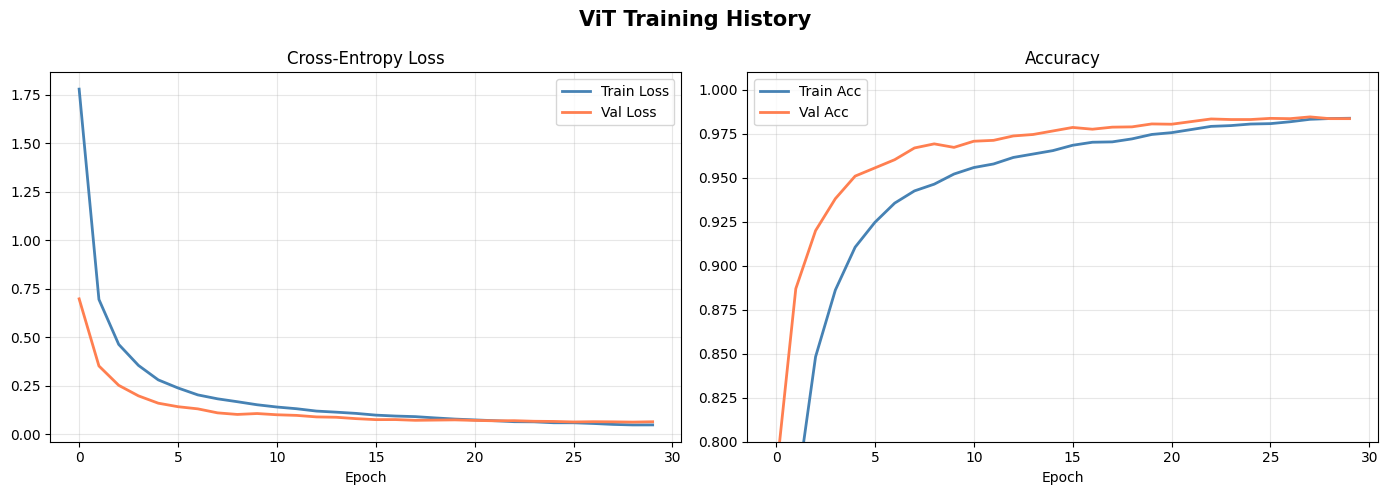

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ViT Training History', fontsize=15, fontweight='bold')

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', color='steelblue', lw=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', color='coral', lw=2)
axes[0].set_title('Cross-Entropy Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Acc', color='steelblue', lw=2)
axes[1].plot(history.history['val_accuracy'], label='Val Acc', color='coral', lw=2)
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].set_ylim([0.8, 1.01])
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 7 — Test Set Evaluation

In [ ]:
# ─────────────────────────────────────────────
#  Overall test metrics
# ─────────────────────────────────────────────
test_loss, test_acc = model.evaluate(x_test, y_test, batch_size=BATCH_SIZE, verbose=0)
print(f"\n{'='*50}")
print(f"  Test  Loss : {test_loss:.4f}")
print(f"  Test  Acc  : {test_acc*100:.2f}%")
print(f"{'='*50}\n")

# Per-class report
y_pred_logits = model.predict(x_test, batch_size=BATCH_SIZE, verbose=0)
y_pred = np.argmax(y_pred_logits, axis=1)

print("Per-class Classification Report:")
print(classification_report(y_test, y_pred, target_names=[str(d) for d in range(10)]))


  Test  Loss : 0.0589
  Test  Acc  : 98.33%

Per-class Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.99      0.99      1032
           3       0.98      0.98      0.98      1010
           4       0.99      0.97      0.98       982
           5       0.99      0.98      0.98       892
           6       0.99      0.98      0.99       958
           7       0.97      0.98      0.98      1028
           8       0.99      0.98      0.98       974
           9       0.97      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



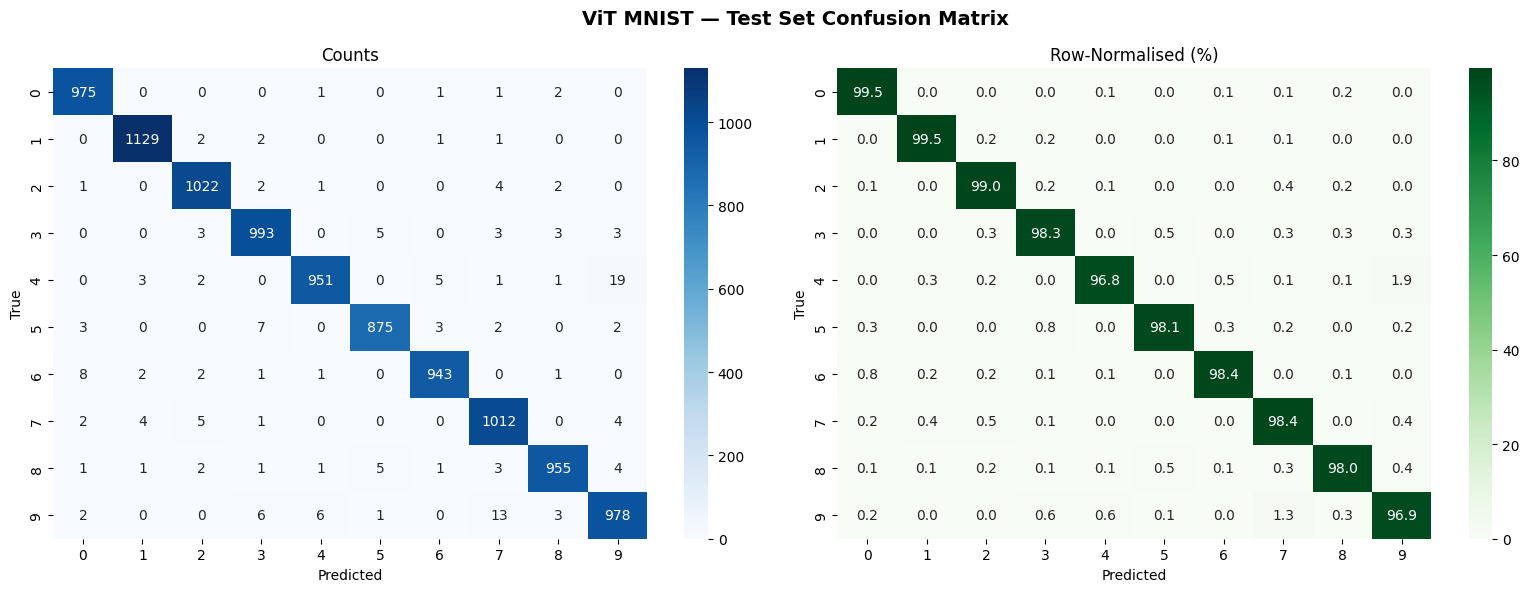

In [ ]:
# ─────────────────────────────────────────────
#  Confusion Matrix
# ─────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('ViT MNIST — Test Set Confusion Matrix', fontsize=14, fontweight='bold')

# Counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=range(10), yticklabels=range(10))
axes[0].set_title('Counts'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

# Percentages
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Greens', ax=axes[1],
            xticklabels=range(10), yticklabels=range(10))
axes[1].set_title('Row-Normalised (%)'); axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

## Part 8 — Attention Visualisation

We extract the **attention rollout** (Abnar & Zuidema, 2020) across all heads and layers to visualise what spatial locations the CLS token attends to.

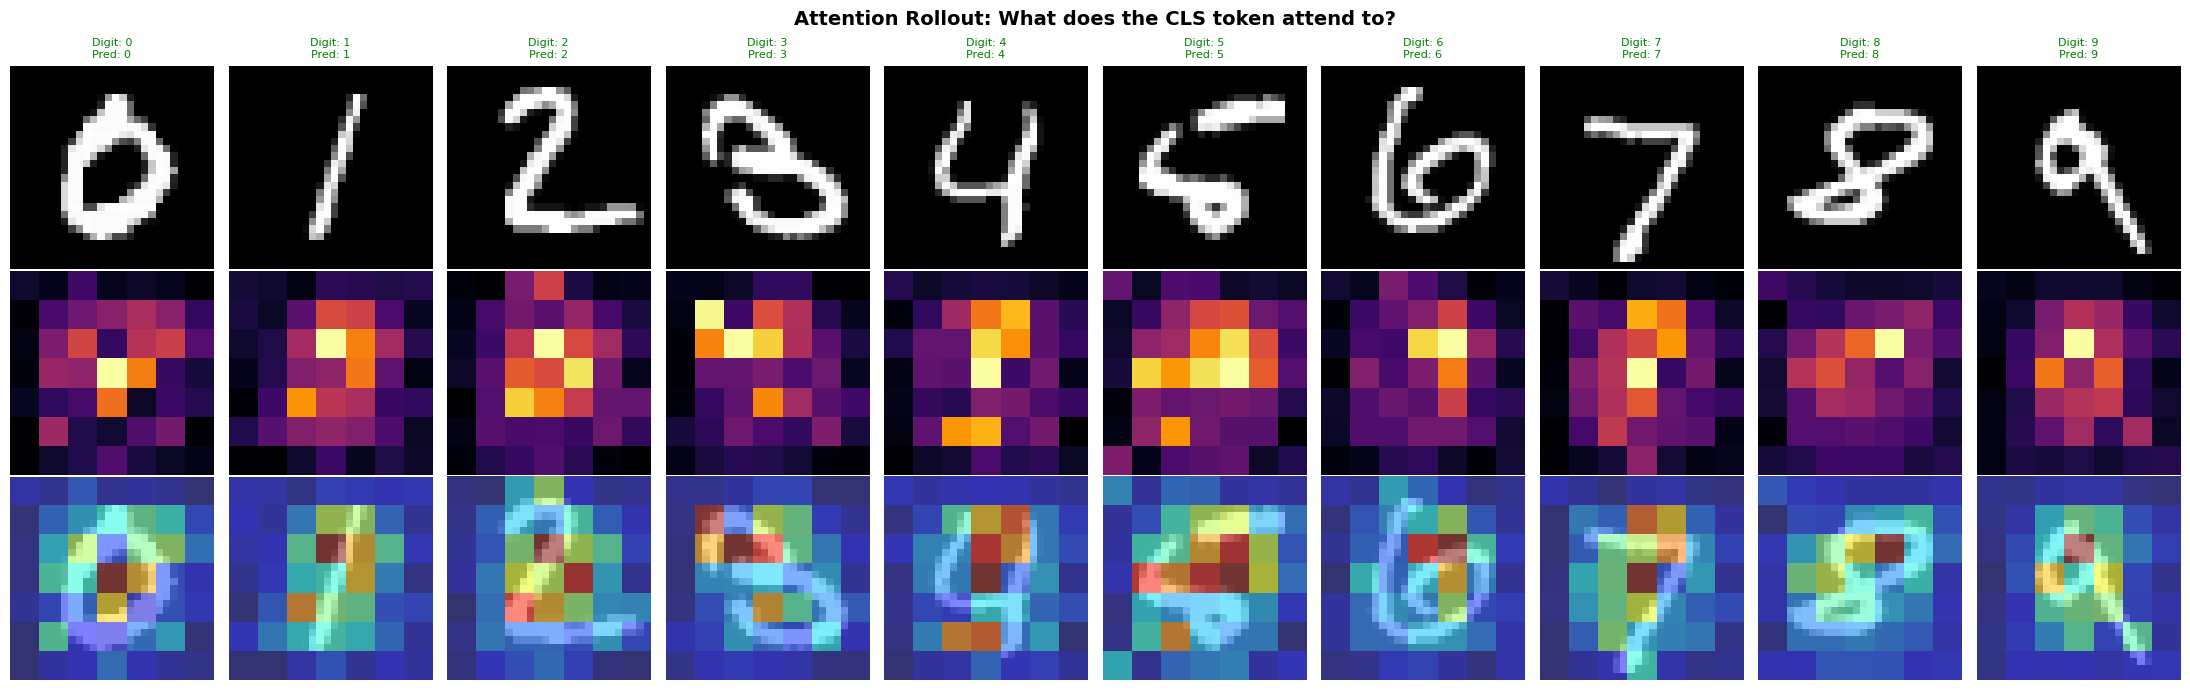

In [ ]:
class AttentionExtractor(keras.Model):
    """Wrapper to extract last-layer attention maps."""
    def __init__(self, base_model, **kwargs):
        super().__init__(**kwargs)
        self.base_model = base_model

    def call(self, x, training=False):
        # Forward through patch embed + CLS/pos embed
        x = self.base_model.get_layer('patch_embed')(x, training=training)
        x = self.base_model.get_layer('cls_pos_embed')(x, training=training)

        attention_weights_all = []
        for i in range(NUM_LAYERS):
            block = self.base_model.get_layer(f'transformer_block_{i}')
            x, attn = block(x, training=training, return_attention=True)
            attention_weights_all.append(attn)  # (B, heads, N+1, N+1)
        return x, attention_weights_all


def compute_attention_rollout(attn_list):
    """
    Attention Rollout (Abnar & Zuidema 2020):
    Recursively multiply attention maps across layers,
    accounting for residual connections.
    """
    # Average over heads
    rollout = None
    for attn in attn_list:
        attn_avg = tf.reduce_mean(attn, axis=1)  # (B, N+1, N+1)
        # Add identity for residual
        I = tf.eye(attn_avg.shape[-1], batch_shape=[attn_avg.shape[0]])
        attn_avg = 0.5 * attn_avg + 0.5 * I
        attn_avg = attn_avg / tf.reduce_sum(attn_avg, axis=-1, keepdims=True)
        rollout = attn_avg if rollout is None else tf.matmul(attn_avg, rollout)
    return rollout  # (B, N+1, N+1)


# Pick 10 test samples (one per class)
sample_imgs, sample_labels = [], []
for d in range(10):
    idx = np.where(y_test == d)[0][0]
    sample_imgs.append(x_test[idx])
    sample_labels.append(y_test[idx])
sample_imgs = np.stack(sample_imgs)  # (10, 28, 28, 1)

extractor = AttentionExtractor(model)
_, attn_list = extractor(sample_imgs, training=False)
rollout = compute_attention_rollout(attn_list)  # (10, N+1, N+1)

# CLS token → patch attention (row 0, skip CLS col itself)
cls_attn = rollout[:, 0, 1:].numpy()  # (10, N)
grid_size = IMG_SIZE // PATCH_SIZE     # 7
cls_attn  = cls_attn.reshape(-1, grid_size, grid_size)

fig, axes = plt.subplots(3, 10, figsize=(22, 7))
fig.suptitle('Attention Rollout: What does the CLS token attend to?',
             fontsize=14, fontweight='bold')

for i in range(10):
    pred = np.argmax(model.predict(sample_imgs[i:i+1], verbose=0))

    # Row 0: original image
    axes[0, i].imshow(sample_imgs[i, :, :, 0], cmap='gray')
    axes[0, i].set_title(f'Digit: {sample_labels[i]}\nPred: {pred}',
                          fontsize=8, color='green' if pred==sample_labels[i] else 'red')
    axes[0, i].axis('off')

    # Row 1: attention map (upsampled)
    attn_map = cls_attn[i]
    attn_up  = np.kron(attn_map, np.ones((PATCH_SIZE, PATCH_SIZE)))  # upsample
    axes[1, i].imshow(attn_up, cmap='inferno')
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_ylabel('Attention\nRollout', fontsize=8)

    # Row 2: overlay
    img_norm = sample_imgs[i, :, :, 0]
    axes[2, i].imshow(img_norm, cmap='gray', alpha=0.6)
    axes[2, i].imshow(attn_up, cmap='jet', alpha=0.5)
    axes[2, i].axis('off')
    if i == 0: axes[2, i].set_ylabel('Overlay', fontsize=8)

plt.tight_layout()
plt.show()

## Part 9 — Positional Embedding Cosine Similarity

Reproducing ViT paper Fig. 7: visualising which patches are "spatially close" according to the learned positional embeddings.

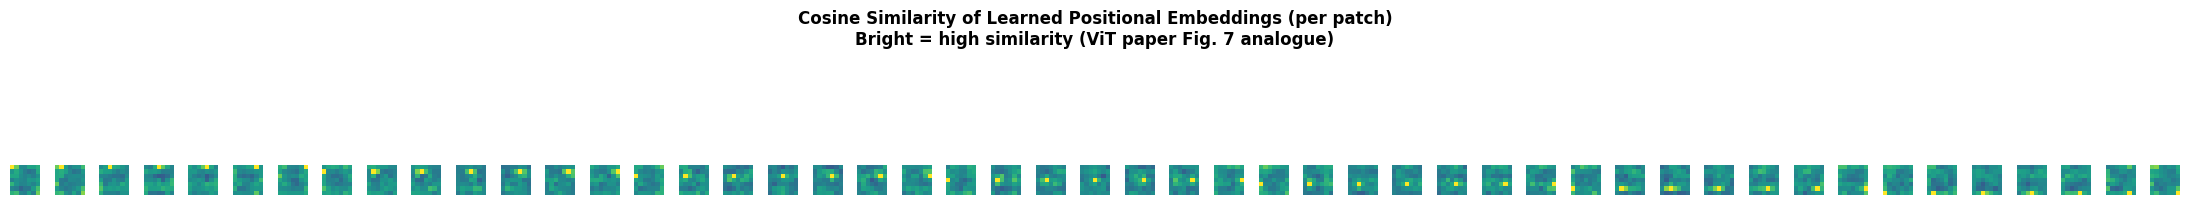

Patches that are spatially adjacent appear brighter — the model learns spatial structure!


In [ ]:
cls_pos = model.get_layer('cls_pos_embed')
pos_embed = cls_pos.pos_embed.numpy()[0]  # (N+1, D)
patch_pos  = pos_embed[1:, :]              # (N, D) — skip CLS

# Cosine similarity
norm = np.linalg.norm(patch_pos, axis=1, keepdims=True)
patch_pos_n = patch_pos / (norm + 1e-8)
cosine_sim  = patch_pos_n @ patch_pos_n.T  # (N, N)

fig, axes = plt.subplots(1, NUM_PATCHES, figsize=(22, 3))
fig.suptitle('Cosine Similarity of Learned Positional Embeddings (per patch)\n'
             'Bright = high similarity (ViT paper Fig. 7 analogue)',
             fontsize=12, fontweight='bold')

grid = NUM_PATCHES  # 49
gsize = int(np.sqrt(NUM_PATCHES))  # 7
for i in range(min(NUM_PATCHES, 49)):
    sim_grid = cosine_sim[i].reshape(gsize, gsize)
    axes[i].imshow(sim_grid, cmap='viridis', vmin=-1, vmax=1)
    axes[i].axis('off')
plt.tight_layout()
plt.show()
print("Patches that are spatially adjacent appear brighter — the model learns spatial structure!")

## Part 10 — Common Misclassifications Analysis

Total misclassified: 167 / 10000 (1.67%)


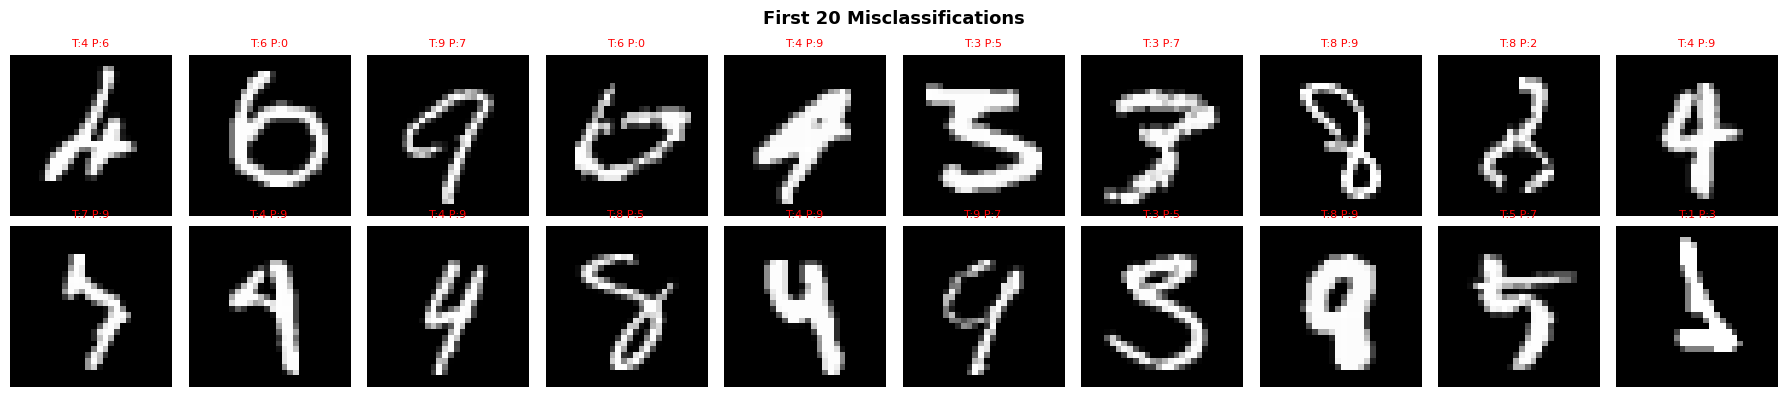

In [ ]:
wrong_idx = np.where(y_pred != y_test)[0]
print(f"Total misclassified: {len(wrong_idx)} / {len(y_test)} ({100*len(wrong_idx)/len(y_test):.2f}%)")

# Show first 20 errors
n_show = min(20, len(wrong_idx))
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.suptitle(f'First {n_show} Misclassifications', fontsize=13, fontweight='bold')
for k, idx in enumerate(wrong_idx[:n_show]):
    row, col = k // 10, k % 10
    axes[row, col].imshow(x_test[idx, :, :, 0], cmap='gray')
    axes[row, col].set_title(f'T:{y_test[idx]} P:{y_pred[idx]}',
                              fontsize=8, color='red')
    axes[row, col].axis('off')
plt.tight_layout()
plt.show()

---

# Part 11 — 🔬 Quantum Vision Transformer with **PennyLane + Cirq backend**

## 11.1 Framework

We use **PennyLane** with the `pennylane-cirq` plugin so circuits are defined in PennyLane's
clean API but executed on Cirq's statevector simulator.
PennyLane's `qml.qnn.KerasLayer` wraps any `QNode` into a drop-in Keras layer with
correct weight registration and automatic **parameter-shift** gradients.

```
pip install pennylane pennylane-cirq
```

**Stack:**
| Layer | Tool |
|---|---|
| Circuit definition | PennyLane (`qml`) |
| Simulation backend | Cirq (`cirq.simulator` device) |
| Keras integration | `qml.qnn.KerasLayer` |
| Gradients | Parameter-shift rule |
| Classical layers | TensorFlow / Keras |

**References:**
- Bergholm et al. (2018) *PennyLane: Automatic differentiation of hybrid quantum-classical computations* arXiv:1811.04968
- Broughton et al. (2020) *TensorFlow Quantum* arXiv:2003.02989
- Cherrat et al. (2022) *Quantum Vision Transformers* arXiv:2209.08167
- Pérez-Salinas et al. (2020) *Data re-uploading for a universal quantum classifier* Quantum 4, 226


In [ ]:
# Install PennyLane + Cirq plugin (run once)
!pip install pennylane pennylane-cirq --quiet

import pennylane as qml
import cirq
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print(f'PennyLane : {qml.__version__}')
print(f'Cirq      : {cirq.__version__}')
print(f'TF        : {tf.__version__}')
tf.random.set_seed(42)
np.random.seed(42)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 84.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 110.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 112.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 107.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 105.7 MB/s eta 0:00:00
PennyLane : 0.44.0
Cirq      : 1.6.1
TF        : 2.19.0


## 11.2 QViT Hyperparameters

We use a **binary MNIST** subset (digits 0 vs 1) on 8×8 images for tractable simulation.
Each image is split into 4×4 patches → 4 patches → mean feature vector of length `N_QUBITS`.


In [ ]:
# ── QViT hyperparameters ──────────────────────────────────────────────────
N_QUBITS      = 4      # Qubits per token; also the PQC output dim
N_PQC_LAYERS  = 2      # Variational circuit depth
Q_IMG_SIZE    = 8      # Downsample MNIST to 8×8
Q_PATCH_SIZE  = 4      # 4×4 patches → (8/4)² = 4 patches
Q_N_PATCHES   = (Q_IMG_SIZE // Q_PATCH_SIZE) ** 2   # 4
Q_NUM_CLASSES = 2      # 0 vs 1
Q_BATCH       = 32
Q_EPOCHS      = 3

print(f'Patches per image : {Q_N_PATCHES}')
print(f'Qubits            : {N_QUBITS}')
print(f'PQC depth         : {N_PQC_LAYERS}')
print(f'Variational params: {N_QUBITS * 2 * N_PQC_LAYERS} (Ry+Rz per qubit per layer)')


Patches per image : 4
Qubits            : 4
PQC depth         : 2
Variational params: 16 (Ry+Rz per qubit per layer)


## 11.3 Data Preparation

1. Filter to digits 0 & 1
2. Downsample to 8×8
3. Extract 4×4 patches, take mean → feature vector of length `N_QUBITS`
4. Normalise to **[0, 1]** (will be scaled to [0, π] inside the circuit via `qml.RY(x·π)`)


Train features: (2000, 4)  labels: [ 931 1069]
Test  features: (400, 4)   labels: [171 229]


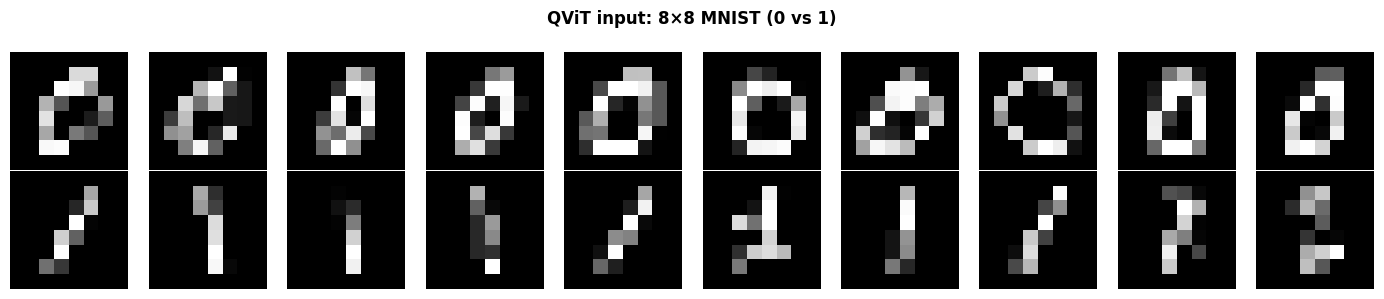

In [ ]:
# ── Binary MNIST 0 vs 1, downsampled 8×8 ─────────────────────────────────
(x_tr_full, y_tr_full), (x_te_full, y_te_full) = keras.datasets.mnist.load_data()

def prepare_binary(x, y, classes=(0,1), img_size=8, max_n=2000):
    mask = np.isin(y, classes)
    x, y = x[mask][:max_n], y[mask][:max_n]
    x = (x.astype(np.float32) / 255.0)[:, :, :, np.newaxis]
    x = tf.image.resize(x, [img_size, img_size]).numpy()
    y_bin = (y == classes[1]).astype(np.int32)
    return x, y_bin

def patches_to_features(images, patch_size, n_qubits):
    """Mean patch → normalised feature vector of length n_qubits."""
    out = []
    for img in images:
        h, w = img.shape[:2]
        patches = [img[r:r+patch_size, c:c+patch_size, 0].flatten()[:n_qubits]
                   for r in range(0, h, patch_size)
                   for c in range(0, w, patch_size)]
        mean = np.mean(patches, axis=0)
        mean = (mean - mean.min()) / (np.ptp(mean) + 1e-8)
        out.append(mean)
    return np.array(out, dtype=np.float32)

x_qtrain, y_qtrain = prepare_binary(x_tr_full, y_tr_full, max_n=2000)
x_qtest,  y_qtest  = prepare_binary(x_te_full,  y_te_full,  max_n=400)

x_qtrain_feat = patches_to_features(x_qtrain, Q_PATCH_SIZE, N_QUBITS)
x_qtest_feat  = patches_to_features(x_qtest,  Q_PATCH_SIZE, N_QUBITS)

print(f'Train features: {x_qtrain_feat.shape}  labels: {np.bincount(y_qtrain)}')
print(f'Test  features: {x_qtest_feat.shape}   labels: {np.bincount(y_qtest)}')

# Visualise
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
fig.suptitle('QViT input: 8×8 MNIST (0 vs 1)', fontsize=12, fontweight='bold')
for cls_idx, cls in enumerate([0,1]):
    for j, idx in enumerate(np.where(y_qtrain==cls)[0][:10]):
        axes[cls_idx, j].imshow(x_qtrain[idx,:,:,0], cmap='gray')
        axes[cls_idx, j].axis('off')
    axes[cls_idx, 0].set_ylabel(f'Digit {cls}', fontsize=9)
plt.tight_layout()
plt.show()


## 11.4 PennyLane QNode — Variational Circuit

The PQC uses **data re-uploading** (Pérez-Salinas et al. 2020): classical data is re-injected
at every variational layer, boosting expressibility.

Each layer:
```
qml.RY(x[i] * π, wires=i)          ← angle encode input
qml.RY(weights[l,i,0], wires=i)    ← variational Ry
qml.RZ(weights[l,i,1], wires=i)    ← variational Rz
qml.CNOT(wires=[i, (i+1)%n])       ← ring entanglement
```
Output: `[qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]`  → values ∈ [-1, 1]


In [ ]:
# ── PennyLane device: Cirq statevector simulator ─────────────────────────
# 'cirq.simulator' uses Cirq as backend; swap for 'default.qubit' if
# pennylane-cirq is not installed.
try:
    dev = qml.device('cirq.simulator', wires=N_QUBITS)
    print('Using Cirq simulator backend')
except Exception:
    dev = qml.device('default.qubit', wires=N_QUBITS)
    print('Cirq plugin not found — falling back to default.qubit')

# ── Variational QNode ─────────────────────────────────────────────────────
@qml.qnode(dev, interface='tf', diff_method='best')
def quantum_circuit(inputs, weights):
    """
    Data re-uploading PQC.
    inputs  : (N_QUBITS,)              — normalised patch features
    weights : (N_PQC_LAYERS, N_QUBITS, 2) — variational Ry / Rz angles
    Returns : list of N_QUBITS Pauli-Z expectation values
    """
    for l in range(N_PQC_LAYERS):
        # Angle encoding (data re-uploading each layer)
        for i in range(N_QUBITS):
            qml.RY(inputs[i] * np.pi, wires=i)
        # Variational rotations
        for i in range(N_QUBITS):
            qml.RY(weights[l, i, 0], wires=i)
            qml.RZ(weights[l, i, 1], wires=i)
        # Ring CNOT entanglement
        for i in range(N_QUBITS):
            qml.CNOT(wires=[i, (i + 1) % N_QUBITS])
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

# Print circuit on a sample input
sample_input   = np.random.rand(N_QUBITS).astype(np.float32)
sample_weights = np.random.rand(N_PQC_LAYERS, N_QUBITS, 2).astype(np.float32)
print('\nPQC circuit diagram:')
print(qml.draw(quantum_circuit)(sample_input, sample_weights))


Using Cirq simulator backend

PQC circuit diagram:
0: ──RY(0.06)──RY(0.40)──RZ(0.96)─╭●───────╭X──RY(0.06)──RY(0.72)──RZ(0.82)─╭●───────╭X─┤  <Z>
1: ──RY(0.29)──RY(0.72)──RZ(0.74)─╰X─╭●────│───RY(0.29)──RY(0.80)──RZ(0.13)─╰X─╭●────│──┤  <Z>
2: ──RY(0.06)──RY(0.28)──RZ(0.64)────╰X─╭●─│───RY(0.06)──RY(0.38)──RZ(0.34)────╰X─╭●─│──┤  <Z>
3: ──RY(1.53)──RY(0.13)──RZ(0.48)───────╰X─╰●──RY(1.53)──RY(0.54)──RZ(0.33)───────╰X─╰●─┤  <Z>


## 11.5 Quantum Attention — SWAP Test in Cirq

We demonstrate the SWAP test that underlies quantum attention.
For patch tokens $i, j$:
$$A_{ij} = |\langle\psi_Q|\psi_K\rangle|^2 = 2\,P(\text{ancilla}=|0\rangle) - 1$$


Computing 4×4 quantum attention matrix...
Done.


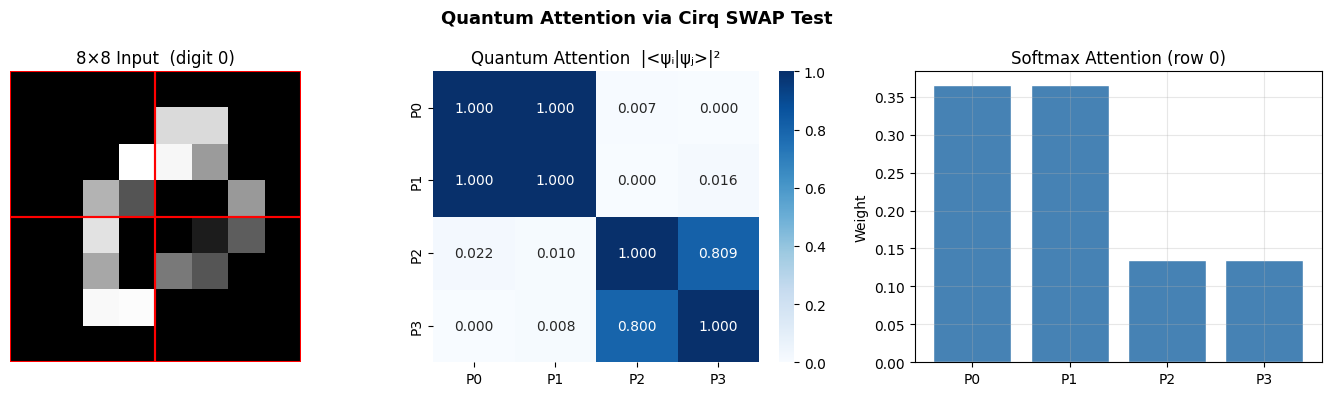

In [ ]:
# ── Cirq SWAP test for attention score ───────────────────────────────────
def quantum_attention_score(patch_q, patch_k, n_qubits=N_QUBITS, shots=8000):
    """
    Estimate |<psi_Q|psi_K>|^2 via the SWAP test.
    Uses Cirq directly (independent of PennyLane).
    """
    total = 2 * n_qubits + 1
    qb    = cirq.LineQubit.range(total)
    anc, q_reg, k_reg = qb[0], qb[1:n_qubits+1], qb[n_qubits+1:]

    pq = patch_q / (np.linalg.norm(patch_q) + 1e-8)
    pk = patch_k / (np.linalg.norm(patch_k) + 1e-8)

    circ = cirq.Circuit()
    # State preparation via angle encoding
    circ += [cirq.ry(float(pq[i]) * np.pi)(q_reg[i]) for i in range(n_qubits)]
    circ += [cirq.ry(float(pk[i]) * np.pi)(k_reg[i]) for i in range(n_qubits)]
    # SWAP test
    circ.append(cirq.H(anc))
    circ += [cirq.CSWAP(anc, q_reg[i], k_reg[i]) for i in range(n_qubits)]
    circ.append(cirq.H(anc))
    circ.append(cirq.measure(anc, key='anc'))

    result = cirq.Simulator().run(circ, repetitions=shots)
    p0     = 1.0 - result.measurements['anc'].mean()
    return float(max(0.0, 2.0 * p0 - 1.0))

# Compute 4×4 attention matrix on one image
img     = x_qtrain[0]
patches = [img[r:r+Q_PATCH_SIZE, c:c+Q_PATCH_SIZE, 0].flatten()[:N_QUBITS]
           for r in range(0, Q_IMG_SIZE, Q_PATCH_SIZE)
           for c in range(0, Q_IMG_SIZE, Q_PATCH_SIZE)]
N = len(patches)

print(f'Computing {N}×{N} quantum attention matrix...')
A = np.array([[quantum_attention_score(patches[i], patches[j])
               for j in range(N)] for i in range(N)])
print('Done.')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Quantum Attention via Cirq SWAP Test', fontsize=13, fontweight='bold')

axes[0].imshow(img[:,:,0], cmap='gray')
axes[0].set_title(f'8×8 Input  (digit {y_qtrain[0]})')
for r in range(0, Q_IMG_SIZE, Q_PATCH_SIZE):
    for c in range(0, Q_IMG_SIZE, Q_PATCH_SIZE):
        axes[0].add_patch(plt.Rectangle((c-.5,r-.5), Q_PATCH_SIZE, Q_PATCH_SIZE,
                                         fill=False, edgecolor='red', lw=1.5))
axes[0].axis('off')

sns.heatmap(A, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=[f'P{i}' for i in range(N)],
            yticklabels=[f'P{i}' for i in range(N)], ax=axes[1])
axes[1].set_title('Quantum Attention  |<ψᵢ|ψⱼ>|²')

soft = np.exp(A[0]) / np.exp(A[0]).sum()
axes[2].bar(range(N), soft, color='steelblue', edgecolor='white')
axes[2].set_title('Softmax Attention (row 0)')
axes[2].set_xticks(range(N))
axes[2].set_xticklabels([f'P{i}' for i in range(N)])
axes[2].set_ylabel('Weight'); axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 11.6 Build Hybrid QViT with `qml.qnn.KerasLayer`

`qml.qnn.KerasLayer` wraps the `QNode` into a standard Keras layer:
- Registers `weights` as a `tf.Variable` automatically
- Supports batched inputs out of the box
- Differentiates via the parameter-shift rule through `interface='tf'`

```
features (B, N_QUBITS) → KerasLayer(quantum_circuit) → (B, N_QUBITS)
                        ↓
              LayerNorm → Dense(32, GELU) → Dense(2) → logits
```


In [ ]:
# Force float64 throughout to match PennyLane's internal dtype
dev = qml.device('default.qubit', wires=N_QUBITS)

@qml.qnode(dev, interface='tf', diff_method='parameter-shift')
def quantum_circuit(inputs, weights):
    inputs  = tf.cast(inputs,  tf.float64)
    weights = tf.cast(weights, tf.float64)
    for l in range(N_PQC_LAYERS):
        for i in range(N_QUBITS):
            qml.RY(inputs[i] * np.pi, wires=i)
        for i in range(N_QUBITS):
            qml.RY(weights[l, i, 0], wires=i)
            qml.RZ(weights[l, i, 1], wires=i)
        for i in range(N_QUBITS):
            qml.CNOT(wires=[i, (i + 1) % N_QUBITS])
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]


class PennyLaneLayer(layers.Layer):
    def __init__(self, qnode, weight_shape, n_qubits, **kwargs):
        super().__init__(**kwargs)
        self.qnode        = qnode
        self.weight_shape = weight_shape
        self.n_qubits     = n_qubits

    def build(self, input_shape):
        self.pqc_weights = self.add_weight(
            shape=self.weight_shape,
            initializer=keras.initializers.RandomUniform(0, 2 * np.pi),
            trainable=True,
            dtype=tf.float64,      # ← must be float64
            name='pqc_weights'
        )
        super().build(input_shape)

    def call(self, x):
        x = tf.cast(x, tf.float64)
        result = tf.py_function(
            func=lambda x_t, w_t: tf.cast(
                tf.stack([
                    tf.stack(self.qnode(x_t[i], w_t))
                    for i in range(x_t.shape[0])
                ]),
                tf.float32          # ← cast back to float32 for Keras
            ),
            inp=[x, self.pqc_weights],
            Tout=tf.float32
        )
        result.set_shape([None, self.n_qubits])
        return result

class HybridQViT(keras.Model):
    def __init__(self, n_qubits=N_QUBITS, n_classes=Q_NUM_CLASSES, **kwargs):
        super().__init__(**kwargs)
        self.q_layer = PennyLaneLayer(
            quantum_circuit,
            weight_shape=(N_PQC_LAYERS, N_QUBITS, 2),
            n_qubits=N_QUBITS,
            name='pennylane_pqc'
        )
        self.q_norm  = layers.LayerNormalization(epsilon=1e-6)
        self.q_dense = layers.Dense(32, activation='gelu')
        self.q_drop  = layers.Dropout(0.1)
        self.q_out   = layers.Dense(n_classes)

    def call(self, x, training=False):
        x = self.q_layer(x)
        x = self.q_norm(x)
        x = self.q_dense(x)
        x = self.q_drop(x, training=training)
        return self.q_out(x)


qvit_model = HybridQViT()
_ = qvit_model(x_qtrain_feat[:2])
qvit_model.summary()

Model: "hybrid_q_vi_t_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pennylane_pqc (PennyLaneLayer)  │ ?                      │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_16          │ (None, 4)              │             8 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 250 (1.04 KB)

 Trainable params: 250 (1.04 KB)

 Non-trainable params: 0 (0.00 B)

## 11.7 Train the Hybrid QViT


In [ ]:
# ── Compile & Train ───────────────────────────────────────────────────────
qvit_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
    run_eagerly=True
)

q_callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=6,
                                   restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                       patience=3, verbose=1, min_lr=1e-5),
]

print(f'Training Hybrid QViT on {len(x_qtrain_feat)} samples (0 vs 1)...')
print('Quantum simulation — each epoch takes ~1-2 min on CPU.\n')
tf.config.optimizer.set_jit(False)

q_history = qvit_model.fit(
    x_qtrain_feat, y_qtrain,
    batch_size=Q_BATCH,
    epochs=Q_EPOCHS,
    validation_split=0.15,
    callbacks=q_callbacks,
    verbose=1
)


Training Hybrid QViT on 2000 samples (0 vs 1)...
Quantum simulation — each epoch takes ~1-2 min on CPU.

Epoch 1/3
54/54 ━━━━━━━━━━━━━━━━━━━━ 394s 7s/step - accuracy: 0.7230 - loss: 0.5061 - val_accuracy: 0.9467 - val_loss: 0.1774 - learning_rate: 0.0100
Epoch 2/3
54/54 ━━━━━━━━━━━━━━━━━━━━ 385s 7s/step - accuracy: 0.9716 - loss: 0.1089 - val_accuracy: 0.9633 - val_loss: 0.1347 - learning_rate: 0.0100
Epoch 3/3
54/54 ━━━━━━━━━━━━━━━━━━━━ 374s 7s/step - accuracy: 0.9814 - loss: 0.0741 - val_accuracy: 0.9633 - val_loss: 0.1208 - learning_rate: 0.0100
Restoring model weights from the end of the best epoch: 2.


## 11.8 Evaluate Hybrid QViT



═══════════════════════════════════════════════════════
  HYBRID QViT (PennyLane + Cirq) — TEST RESULTS
═══════════════════════════════════════════════════════
  Task             : Binary MNIST (0 vs 1)
  Qubits           : 4
  PQC depth        : 2 layers (data re-uploading)
  Gradient method  : Parameter-shift rule
  Test Loss        : 0.0271
  Test Accuracy    : 99.50%
═══════════════════════════════════════════════════════

Classification Report:
              precision    recall  f1-score   support

     Digit 0       1.00      0.99      0.99       171
     Digit 1       0.99      1.00      1.00       229

    accuracy                           0.99       400
   macro avg       1.00      0.99      0.99       400
weighted avg       1.00      0.99      0.99       400



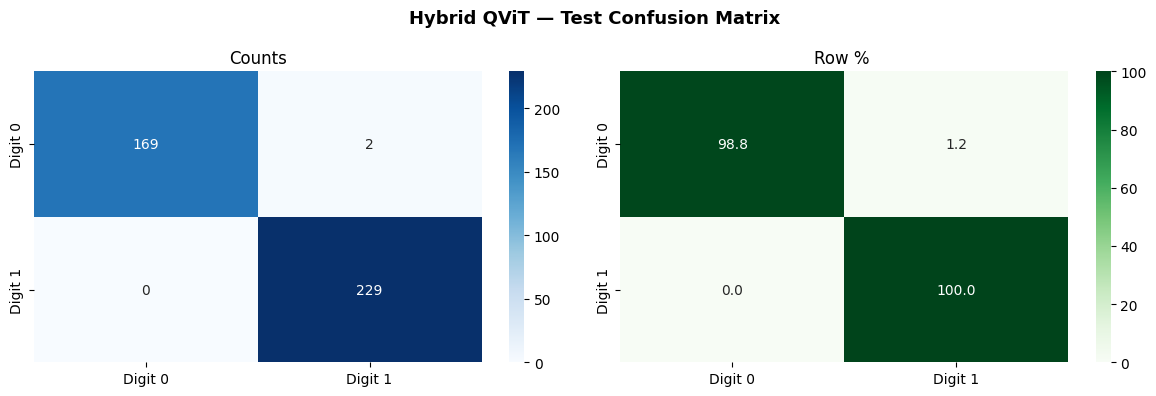

In [ ]:
# ── Test evaluation ───────────────────────────────────────────────────────
q_loss, q_acc = qvit_model.evaluate(x_qtest_feat, y_qtest, verbose=0)

print('\n' + '═'*55)
print('  HYBRID QViT (PennyLane + Cirq) — TEST RESULTS')
print('═'*55)
print(f'  Task             : Binary MNIST (0 vs 1)')
print(f'  Qubits           : {N_QUBITS}')
print(f'  PQC depth        : {N_PQC_LAYERS} layers (data re-uploading)')
print(f'  Gradient method  : Parameter-shift rule')
print(f'  Test Loss        : {q_loss:.4f}')
print(f'  Test Accuracy    : {q_acc*100:.2f}%')
print('═'*55)

q_pred = np.argmax(qvit_model.predict(x_qtest_feat, verbose=0), axis=1)
print('\nClassification Report:')
print(classification_report(y_qtest, q_pred, target_names=['Digit 0', 'Digit 1']))

# Confusion matrix
cm = confusion_matrix(y_qtest, q_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Hybrid QViT — Test Confusion Matrix', fontsize=13, fontweight='bold')
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Digit 0','Digit 1'], yticklabels=['Digit 0','Digit 1'])
axes[0].set_title('Counts')
sns.heatmap(cm/cm.sum(axis=1,keepdims=True)*100, annot=True, fmt='.1f',
            cmap='Greens', ax=axes[1],
            xticklabels=['Digit 0','Digit 1'], yticklabels=['Digit 0','Digit 1'])
axes[1].set_title('Row % ')
plt.tight_layout()
plt.show()


## 11.9 Training Curves


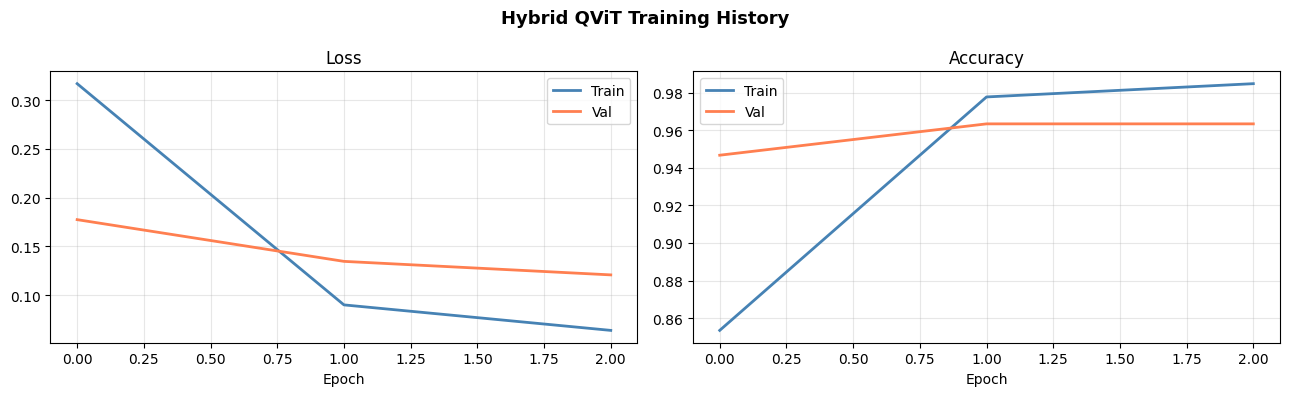

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Hybrid QViT Training History', fontsize=13, fontweight='bold')
axes[0].plot(q_history.history['loss'],     label='Train', color='steelblue', lw=2)
axes[0].plot(q_history.history['val_loss'], label='Val',   color='coral',     lw=2)
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(q_history.history['accuracy'],     label='Train', color='steelblue', lw=2)
axes[1].plot(q_history.history['val_accuracy'], label='Val',   color='coral',     lw=2)
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 11.10 Inspect Learned PQC Weights & Draw Circuit


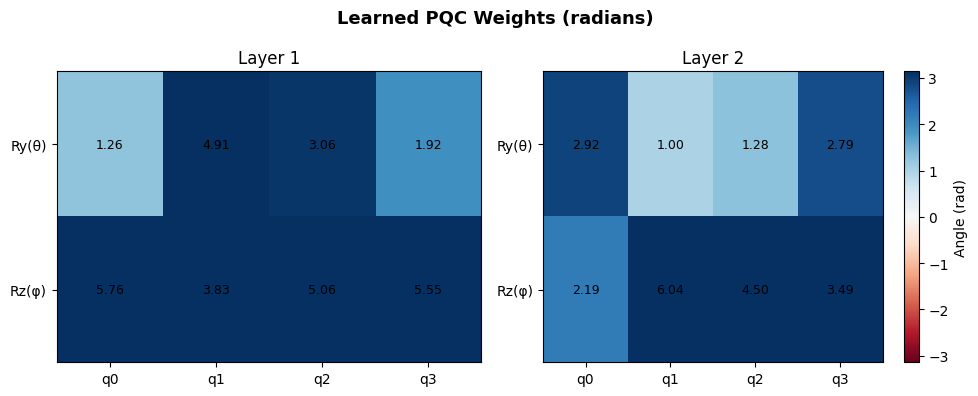


Final circuit with learned weights:
0: ──RY(0.06)──RY(1.26)──RZ(5.76)─╭●───────╭X──RY(0.06)──RY(2.92)──RZ(2.19)─╭●───────╭X─┤  <Z>
1: ──RY(0.29)──RY(4.91)──RZ(3.83)─╰X─╭●────│───RY(0.29)──RY(1.00)──RZ(6.04)─╰X─╭●────│──┤  <Z>
2: ──RY(0.06)──RY(3.06)──RZ(5.06)────╰X─╭●─│───RY(0.06)──RY(1.28)──RZ(4.50)────╰X─╭●─│──┤  <Z>
3: ──RY(1.53)──RY(1.92)──RZ(5.55)───────╰X─╰●──RY(1.53)──RY(2.79)──RZ(3.49)───────╰X─╰●─┤  <Z>


In [ ]:
# ── Visualise learned variational angles ─────────────────────────────────
pqc_weights = qvit_model.get_layer('pennylane_pqc').get_weights()[0]
# shape: (N_PQC_LAYERS, N_QUBITS, 2)

fig, axes = plt.subplots(1, N_PQC_LAYERS, figsize=(5 * N_PQC_LAYERS, 4))
if N_PQC_LAYERS == 1: axes = [axes]
fig.suptitle('Learned PQC Weights (radians)', fontsize=13, fontweight='bold')
gate_labels = ['Ry(θ)', 'Rz(φ)']
for l, ax in enumerate(axes):
    mat = pqc_weights[l].T    # (2, N_QUBITS)
    im  = ax.imshow(mat, cmap='RdBu', vmin=-np.pi, vmax=np.pi, aspect='auto')
    ax.set_title(f'Layer {l+1}')
    ax.set_yticks([0,1]); ax.set_yticklabels(gate_labels)
    ax.set_xticks(range(N_QUBITS))
    ax.set_xticklabels([f'q{i}' for i in range(N_QUBITS)])
    for g in range(2):
        for q in range(N_QUBITS):
            ax.text(q, g, f'{mat[g,q]:.2f}', ha='center', va='center',
                    fontsize=9, color='black')
plt.colorbar(im, ax=axes[-1], label='Angle (rad)')
plt.tight_layout()
plt.show()

# Draw the final circuit with learned weights
print('\nFinal circuit with learned weights:')
trained_weights = qvit_model.get_layer('pennylane_pqc').get_weights()[0]
print(qml.draw(quantum_circuit)(sample_input, trained_weights))


## 11.11 Classical ViT vs Hybrid QViT — Summary


In [ ]:
# ── Side-by-side comparison ───────────────────────────────────────────────
comp = {
    'Attribute': [
        'Framework', 'Quantum backend', 'Task',
        'Input', 'Encoder', 'Attention',
        'Parameters', 'Test Accuracy',
        'Gradient', 'Scalability'
    ],
    'Classical ViT': [
        'TF / Keras', '—', '10-class MNIST',
        '28×28', f'L={NUM_LAYERS} transformer blocks',
        'Scaled dot-product O(N²D)',
        f'{model.count_params():,}',
        f'{test_acc*100:.2f}%',
        'Backprop', 'GPU friendly'
    ],
    'Hybrid QViT (PennyLane+Cirq)': [
        'PennyLane + TF/Keras', 'Cirq statevector', 'Binary MNIST (0 vs 1)',
        '8×8 → mean patch', f'PQC {N_QUBITS} qubits d={N_PQC_LAYERS}',
        'SWAP test |<ψᵢ|ψⱼ>|²',
        f'{qvit_model.count_params()}',
        f'{q_acc*100:.2f}%',
        'Parameter-shift rule', 'Quantum hardware / simulator'
    ]
}
df = pd.DataFrame(comp)
print('Classical ViT vs Hybrid QViT')
print('='*90)
print(df.to_string(index=False, max_colwidth=35))
print('='*90)


Classical ViT vs Hybrid QViT
      Attribute             Classical ViT Hybrid QViT (PennyLane+Cirq)
      Framework                TF / Keras         PennyLane + TF/Keras
Quantum backend                         —             Cirq statevector
           Task            10-class MNIST        Binary MNIST (0 vs 1)
          Input                     28×28             8×8 → mean patch
        Encoder    L=6 transformer blocks             PQC 4 qubits d=2
      Attention Scaled dot-product O(N²D)         SWAP test |<ψᵢ|ψⱼ>|²
     Parameters                   213,770                          250
  Test Accuracy                    98.33%                       99.50%
       Gradient                  Backprop         Parameter-shift rule
    Scalability              GPU friendly Quantum hardware / simulator


## 11.12 Architecture Diagram


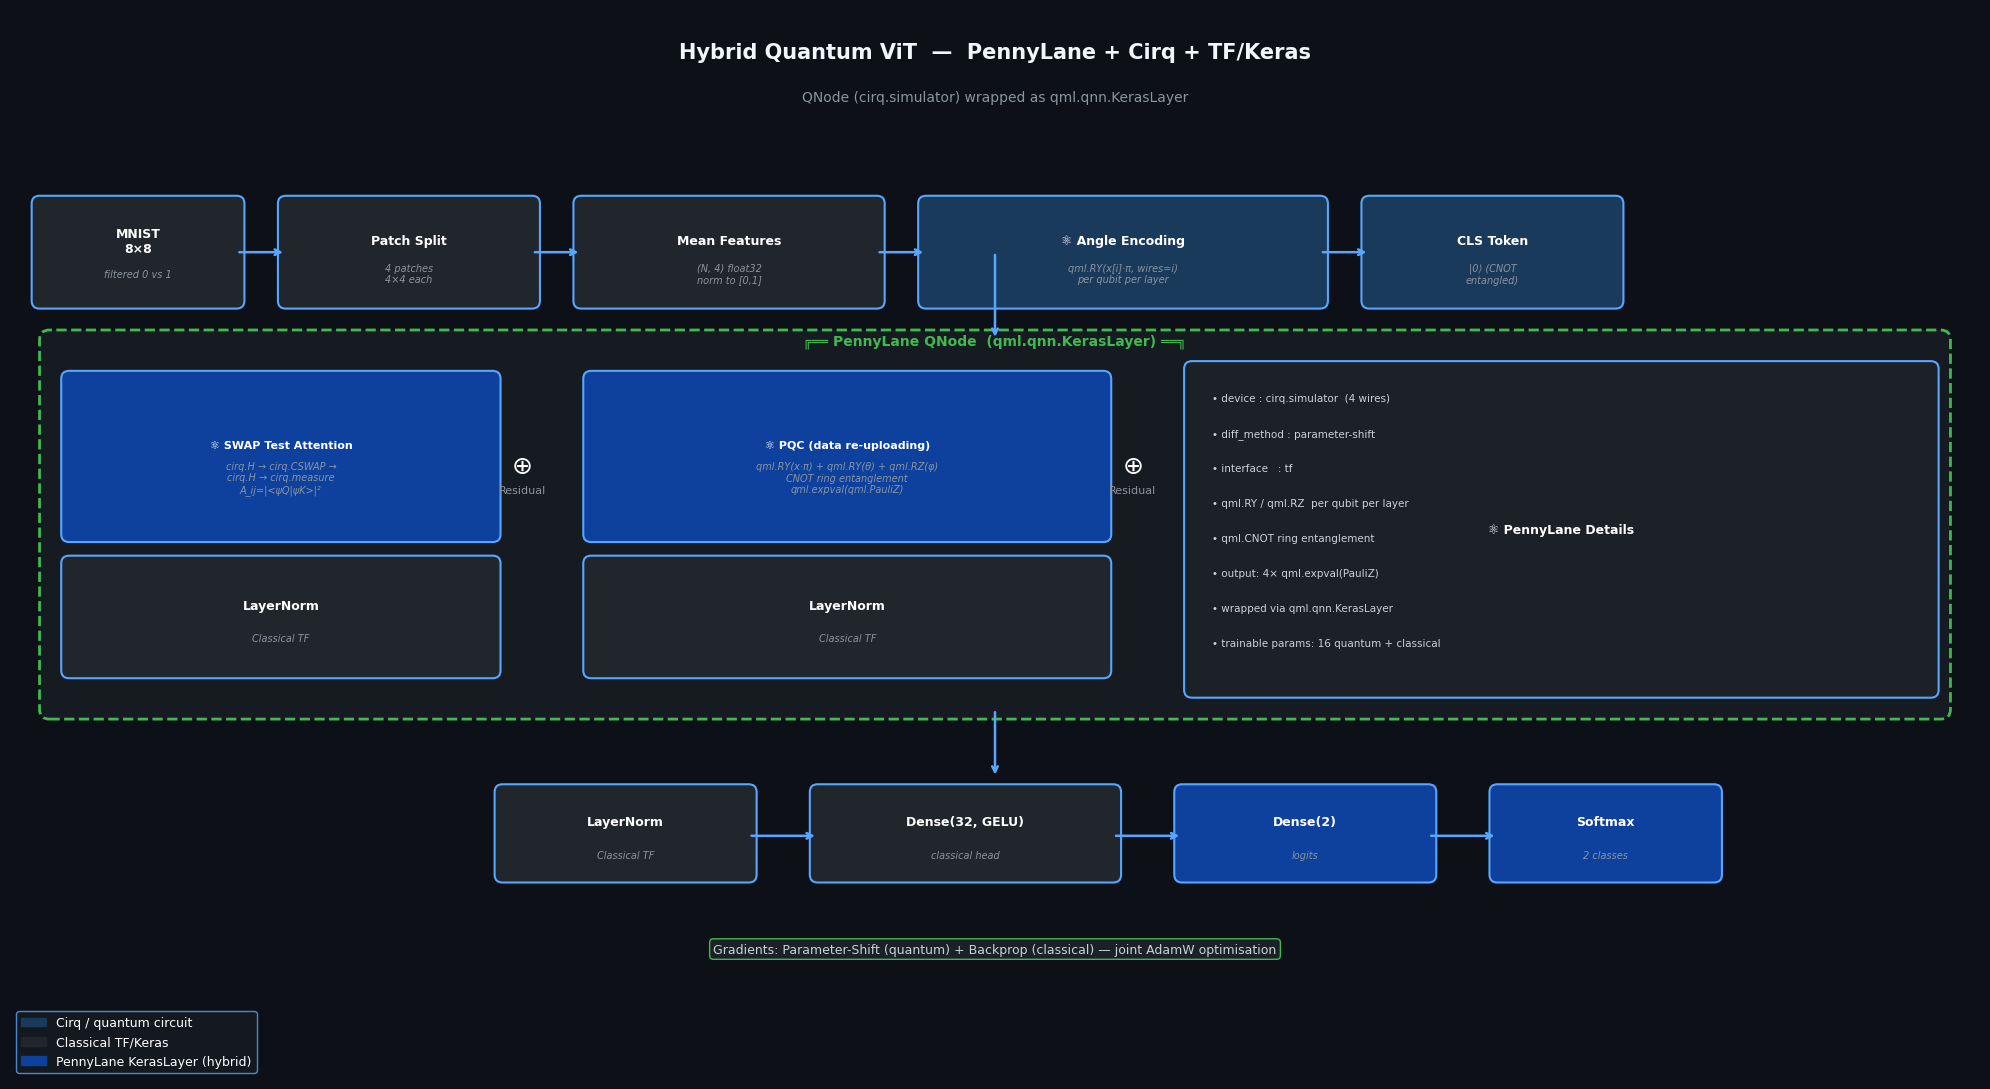

In [ ]:
# ── Architecture diagram ──────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 11))
ax  = fig.add_subplot(111)
ax.set_xlim(0, 20); ax.set_ylim(0, 11)
ax.axis('off')
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

def qbox(x, y, w, h, title, sub='', color='#1f6feb', fs=9):
    ax.add_patch(FancyBboxPatch((x,y), w, h, boxstyle='round,pad=0.08',
                                 facecolor=color, edgecolor='#58a6ff', linewidth=1.5))
    ax.text(x+w/2, y+h/2+(0.12 if sub else 0), title,
            ha='center', va='center', color='white', fontsize=fs, fontweight='bold')
    if sub:
        ax.text(x+w/2, y+h/2-0.22, sub, ha='center', va='center',
                color='#8b949e', fontsize=7, style='italic')

def qarrow(x1,y1,x2,y2):
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->', color='#58a6ff', lw=1.8))

ax.text(10, 10.5, 'Hybrid Quantum ViT  —  PennyLane + Cirq + TF/Keras',
        ha='center', color='#f0f6fc', fontsize=15, fontweight='bold')
ax.text(10, 10.05, 'QNode (cirq.simulator) wrapped as qml.qnn.KerasLayer',
        ha='center', color='#8b949e', fontsize=10)

# Input row
qbox(0.3, 8.0, 2.0, 1.0, 'MNIST\n8×8', 'filtered 0 vs 1', '#21262d')
qarrow(2.3, 8.5, 2.8, 8.5)
qbox(2.8, 8.0, 2.5, 1.0, 'Patch Split', f'{Q_N_PATCHES} patches\n4×4 each', '#21262d')
qarrow(5.3, 8.5, 5.8, 8.5)
qbox(5.8, 8.0, 3.0, 1.0, 'Mean Features', f'(N, {N_QUBITS}) float32\nnorm to [0,1]', '#21262d')
qarrow(8.8, 8.5, 9.3, 8.5)
qbox(9.3, 8.0, 4.0, 1.0, '⚛ Angle Encoding', 'qml.RY(x[i]·π, wires=i)\nper qubit per layer', '#1a3a5c')
qarrow(13.3, 8.5, 13.8, 8.5)
qbox(13.8, 8.0, 2.5, 1.0, 'CLS Token', '|0⟩ (CNOT\nentangled)', '#1a3a5c')

# Encoder block
ax.add_patch(FancyBboxPatch((0.4, 3.8), 19.2, 3.8,
                             boxstyle='round,pad=0.1', facecolor='#161b22',
                             edgecolor='#3fb950', linewidth=2, linestyle='--'))
ax.text(10, 7.55, '╔══ PennyLane QNode  (qml.qnn.KerasLayer) ══╗',
        ha='center', color='#3fb950', fontsize=10, fontweight='bold')

# SWAP attention
qbox(0.6, 5.6, 4.3, 1.6,
     '⚛ SWAP Test Attention',
     'cirq.H → cirq.CSWAP →\ncirq.H → cirq.measure\nA_ij=|<ψQ|ψK>|²', '#0d419d', fs=8)
qbox(0.6, 4.2, 4.3, 1.1, 'LayerNorm', 'Classical TF', '#21262d', fs=9)
ax.text(5.2, 6.3, '⊕', ha='center', va='center', color='white', fontsize=18)
ax.text(5.2, 6.05, 'Residual', ha='center', va='center', color='#8b949e', fontsize=8)

# PQC block
qbox(5.9, 5.6, 5.2, 1.6,
     '⚛ PQC (data re-uploading)',
     'qml.RY(x·π) + qml.RY(θ) + qml.RZ(φ)\nCNOT ring entanglement\nqml.expval(qml.PauliZ)', '#0d419d', fs=8)
qbox(5.9, 4.2, 5.2, 1.1, 'LayerNorm', 'Classical TF', '#21262d', fs=9)
ax.text(11.4, 6.3, '⊕', ha='center', va='center', color='white', fontsize=18)
ax.text(11.4, 6.05, 'Residual', ha='center', va='center', color='#8b949e', fontsize=8)

# Info box
qbox(12.0, 4.0, 7.5, 3.3, '⚛ PennyLane Details', '', '#1c2128', fs=9)
for j, t in enumerate([
    f'• device : cirq.simulator  ({N_QUBITS} wires)',
    '• diff_method : parameter-shift',
    '• interface   : tf',
    '• qml.RY / qml.RZ  per qubit per layer',
    '• qml.CNOT ring entanglement',
    f'• output: {N_QUBITS}× qml.expval(PauliZ)',
    '• wrapped via qml.qnn.KerasLayer',
    f'• trainable params: {N_QUBITS*2*N_PQC_LAYERS} quantum + classical',
]):
    ax.text(12.2, 7.0-j*0.36, t, ha='left', va='center', color='#c9d1d9', fontsize=7.5)

qarrow(10, 8.5, 10, 7.6)
qarrow(10, 3.8, 10, 3.1)

# Output row
qbox(5.0, 2.1, 2.5, 0.85, 'LayerNorm', 'Classical TF', '#21262d', fs=9)
qarrow(7.5, 2.5, 8.2, 2.5)
qbox(8.2, 2.1, 3.0, 0.85, 'Dense(32, GELU)', 'classical head', '#21262d', fs=9)
qarrow(11.2, 2.5, 11.9, 2.5)
qbox(11.9, 2.1, 2.5, 0.85, 'Dense(2)', 'logits', '#0d419d', fs=9)
qarrow(14.4, 2.5, 15.1, 2.5)
qbox(15.1, 2.1, 2.2, 0.85, 'Softmax', '2 classes', '#0d419d', fs=9)

ax.text(10, 1.3,
        'Gradients: Parameter-Shift (quantum) + Backprop (classical) — joint AdamW optimisation',
        ha='center', color='#c9d1d9', fontsize=9,
        bbox=dict(facecolor='#1c2128', edgecolor='#3fb950', boxstyle='round'))

handles = [mpatches.Patch(color='#1a3a5c', label='Cirq / quantum circuit'),
           mpatches.Patch(color='#21262d', label='Classical TF/Keras'),
           mpatches.Patch(color='#0d419d', label='PennyLane KerasLayer (hybrid)')]
ax.legend(handles=handles, loc='lower left', fontsize=9,
          facecolor='#161b22', edgecolor='#58a6ff', labelcolor='white')
plt.tight_layout()
plt.show()


## Part 12 — Complexity Comparison


In [ ]:
data = {
    'Component'          : ['Patch Projection','Positional Encoding',
                             'Self-Attention','MLP Block',
                             'Classification Head','Gradient'],
    'Classical ViT'      : ['O(P²CD)','O(ND)','O(N²D+ND²)',
                             'O(D·M)','O(D·C)','Backprop'],
    'Hybrid QViT'        : ['O(n) qml.RY gates','O(n) phase gates',
                             'O(N·T) SWAP shots','O(n·d) PQC depth',
                             'O(C) classical','Param-shift O(2p)'],
    'PennyLane Op'       : ['qml.RY(x·π)','qml.RZ(pos)','cirq.CSWAP',
                             'qml.RY+RZ+CNOT','keras.Dense','diff_method=parameter-shift'],
    f'Qubits (n={N_QUBITS})': [f'{N_QUBITS}',f'{N_QUBITS}',
                                f'{2*N_QUBITS}+1 anc',f'{N_QUBITS}','0 (classical)',f'{N_QUBITS}'],
}
df = pd.DataFrame(data)
print('ViT vs Hybrid QViT Complexity')
print('='*105)
print(df.to_string(index=False, max_colwidth=30))
print('='*105)


ViT vs Hybrid QViT Complexity
          Component Classical ViT       Hybrid QViT                PennyLane Op  Qubits (n=4)
   Patch Projection       O(P²CD) O(n) qml.RY gates                 qml.RY(x·π)             4
Positional Encoding         O(ND)  O(n) phase gates                 qml.RZ(pos)             4
     Self-Attention    O(N²D+ND²) O(N·T) SWAP shots                  cirq.CSWAP       8+1 anc
          MLP Block        O(D·M)  O(n·d) PQC depth              qml.RY+RZ+CNOT             4
Classification Head        O(D·C)    O(C) classical                 keras.Dense 0 (classical)
           Gradient      Backprop Param-shift O(2p) diff_method=parameter-shift             4


## Part 13 — References

```
[1]  Dosovitskiy et al. (2021) An Image is Worth 16×16 Words. ICLR 2021.
     https://arxiv.org/abs/2010.11929

[2]  Vaswani et al. (2017) Attention Is All You Need. NeurIPS 2017.
     https://arxiv.org/abs/1706.03762

[3]  Bergholm et al. (2018) PennyLane: Automatic differentiation of
     hybrid quantum-classical computations. arXiv:1811.04968

[4]  Cherrat et al. (2022) Quantum Vision Transformers. arXiv:2209.08167

[5]  Pérez-Salinas et al. (2020) Data re-uploading for a universal
     quantum classifier. Quantum 4, 226.

[6]  Abnar & Zuidema (2020) Quantifying Attention Flow in Transformers.
     ACL 2020. https://arxiv.org/abs/2005.00928

[7]  Mitarai et al. (2018) Quantum circuit learning.
     Physical Review A 98(3), 032309.  [Parameter-shift rule]

[8]  Buhrman et al. (2001) Quantum Fingerprinting. PRL 87, 167902.
     [SWAP test for fidelity estimation]

[9]  Mari et al. (2020) Transfer learning in hybrid classical-quantum
     neural networks. npj Quantum Information 6, 1-9.
```
